# Autonomous Enterprise Incident Resolution Engine
### Proof-of-Concept Agent Loop with LangGraph & LangChain

This notebook implements an end-to-end, runnable proof-of-concept for the **Autonomous Enterprise Incident Resolution Engine**.

Rather than treating incident triage as a single conversational LLM prompt, this engine models incident resolution as a **deterministic, policy-controlled state machine** orchestrated by **LangGraph**, where **LangChain** and a local LLM (**Qwen2.5:7b** via Ollama) perform autonomous hypothesis generation, multi-step investigation, and evidence synthesis.

---

### End-to-End Operational Workflow

```text
MessageQueue (Incoming Alert Batch)
    ↓
[detect_trigger] : Normalize alerts into unified event schema
    ↓
[correlate_alerts] : Cluster alerts by topology, time window, & dependencies → Incident
    ↓
[retrieve_context] : Vector search Knowledge Base for historical incidents & runbooks
    ↓
┌─── [investigate] <───────────────────────────────────────────────────────┐
│       ↓                                                                  │
│   Reason about evidence & hypotheses                                     │
│       ↓                                                                  │
│   (Need more evidence?) ─── YES ──> [execute_investigation_tool] ────────┘
│       ↓ NO                                  (Logs, Metrics, Deployments, KB)
│   Sufficient evidence gathered
│       ↓
[decide_root_cause] : Identify primary root cause & confidence score
    ↓
[decide_remediation] : Select fix & evaluate operational risk (LOW vs HIGH)
    ↓
(Policy / Risk Check)
   ├── HIGH RISK ──> [human_approval] (LangGraph interrupt() + checkpoint pause)
   │                      ↓ (Resumed by human)
   └── LOW RISK  ───────> [execute_remediation] : Safely mutate synthetic environment
                              ↓
                         [verify_remediation] : Check health & telemetry post-fix
                              ├── RECOVERED ────> [update_knowledge_base] : Index post-mortem
                              └── UNRECOVERED ──> [close_incident] : Escalate to human
                                                        ↓
                                                   [close_incident] : Finalize status & Audit Log
```

---

### Core Engineering Principles
1. **LangGraph State Machine**: Workflow routing, conditional branches, and human-in-the-loop pauses are strictly deterministic Python/LangGraph logic.
2. **True Closed-Loop Investigation**: The agent reasons, selects an operational tool, observes the structured output, updates hypotheses, and repeats until confident.
3. **Structured Domain Models**: Strict Pydantic models for Alerts, Incidents, Evidence, Hypotheses, Remediation, and Audit Events.
4. **Resumable Human-in-the-Loop (HITL)**: LangGraph `interrupt()` and `MemorySaver` checkpointing pause the graph at high-risk actions without losing state.
5. **Dynamic Operational Memory**: Newly resolved incidents are dynamically indexed into the vector store (`InMemoryVectorStore` with `bge-m3:latest`) for future retrieval.


## SECTION 1 — Environment and Configuration

We configure our local environment, centralize all model and runtime settings, and perform a health check against the local Ollama instance.

- **Chat Model**: `qwen2.5:7b`
- **Embeddings Model**: `bge-m3:latest`
- **Ollama Host**: `http://localhost:11434`
- **Vector Store**: `InMemoryVectorStore` (LangChain Core)
- **Checkpointer**: `MemorySaver` (LangGraph)


In [1]:
import os
import sys
import json
import time
import uuid
import operator
import urllib.request
from datetime import datetime, timezone
from typing import List, Dict, Any, Optional, Literal, Annotated, TypedDict, Union

from pydantic import BaseModel, Field
from IPython.display import Image, display

from langchain_core.tools import tool
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage
from langchain_core.documents import Document
from langchain_core.vectorstores import InMemoryVectorStore
from langchain_ollama import ChatOllama, OllamaEmbeddings
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command

# Universal accessor helper for objects or dicts (deserialized from checkpointer)
def get_attr_or_key(obj: Any, key: str, default: Any = None) -> Any:
    if obj is None:
        return default
    if isinstance(obj, dict):
        return obj.get(key, default)
    return getattr(obj, key, default)

# Centralized Configuration
CONFIG = {
    "OLLAMA_BASE_URL": os.getenv("LLM_BASE_URL", "http://localhost:11434"),
    "CHAT_MODEL": os.getenv("LLM_MODEL", "qwen2.5:7b"),
    "EMBEDDING_MODEL": os.getenv("EMBEDDING_MODEL", "bge-m3:latest"),
    "MAX_INVESTIGATION_STEPS": 4,
    "HIGH_RISK_ACTIONS": ["rollback_deployment", "restart_database", "modify_security_rules"],
    "LOW_RISK_ACTIONS": ["clear_cache", "recycle_connection_pool", "scale_replicas"],
}

print(f"[CONFIG] Base URL: {CONFIG['OLLAMA_BASE_URL']}")
print(f"[CONFIG] Chat Model: {CONFIG['CHAT_MODEL']}")
print(f"[CONFIG] Embedding Model: {CONFIG['EMBEDDING_MODEL']}")
print(f"[CONFIG] Max Investigation Steps: {CONFIG['MAX_INVESTIGATION_STEPS']}")

def verify_ollama_environment(base_url: str, chat_model: str, embed_model: str) -> bool:
    """Check whether local Ollama is running and required models are pulled."""
    try:
        req = urllib.request.Request(f"{base_url}/api/tags", method="GET")
        with urllib.request.urlopen(req, timeout=5) as response:
            if response.status == 200:
                data = json.loads(response.read().decode("utf-8"))
                models = [m.get("name") for m in data.get("models", [])]
                print(f"[HEALTH] Ollama is active. Found {len(models)} local models.")
                
                # Check chat model
                chat_found = any(chat_model in m for m in models)
                embed_found = any(embed_model in m for m in models)
                
                print(f"[HEALTH] Chat model '{chat_model}': {'AVAILABLE' if chat_found else 'MISSING'}")
                print(f"[HEALTH] Embed model '{embed_model}': {'AVAILABLE' if embed_found else 'MISSING'}")
                
                if not (chat_found and embed_found):
                    print("[WARNING] One or more preferred models not found. Please run:")
                    print(f"          ollama pull {chat_model}")
                    print(f"          ollama pull {embed_model}")
                return True
    except Exception as e:
        print(f"[ERROR] Could not connect to Ollama at {base_url}: {e}")
        print("[ERROR] Please start Ollama by running 'ollama serve' in a terminal.")
        return False

# Run environment verification
ollama_ready = verify_ollama_environment(
    CONFIG["OLLAMA_BASE_URL"],
    CONFIG["CHAT_MODEL"],
    CONFIG["EMBEDDING_MODEL"]
)

# Initialize LLM and Embeddings
llm = ChatOllama(
    model=CONFIG["CHAT_MODEL"],
    base_url=CONFIG["OLLAMA_BASE_URL"],
    temperature=0.0
)

embeddings = OllamaEmbeddings(
    model=CONFIG["EMBEDDING_MODEL"],
    base_url=CONFIG["OLLAMA_BASE_URL"]
)


[CONFIG] Base URL: http://localhost:11434
[CONFIG] Chat Model: qwen2.5:7b
[CONFIG] Embedding Model: bge-m3:latest
[CONFIG] Max Investigation Steps: 4
[HEALTH] Ollama is active. Found 10 local models.
[HEALTH] Chat model 'qwen2.5:7b': AVAILABLE
[HEALTH] Embed model 'bge-m3:latest': AVAILABLE


## SECTION 2 — Define the Domain Models

Production-grade incident response demands strongly typed structures for domain objects. We define Pydantic v2 models for:
- **`Alert`**: Heterogeneous alerts ingested from message queues / telemetry collectors.
- **`Incident`**: Aggregated operational incident created through correlation.
- **`Evidence`**: Atomic findings gathered from operational tools.
- **`Hypothesis`**: Working explanations tracked and refined across the investigation loop.
- **`InvestigationStep`**: Auditable record of each diagnostic cycle (Question → Tool → Observation → Hypothesis update).
- **`RemediationAction`**: Bounded, policy-governed remediation definition with risk classification.
- **`AuditEvent`**: Structured log event for the complete lifecycle timeline.


In [2]:
class Alert(BaseModel):
    """Normalized incoming operational alert."""
    id: str = Field(description="Unique alert identifier")
    timestamp: str = Field(description="ISO timestamp of alert occurrence")
    service: str = Field(description="Target service name")
    severity: Literal["P1", "P2", "P3", "P4"] = Field(description="Alert severity tier")
    title: str = Field(description="Short descriptive title")
    message: str = Field(description="Detailed error or event description")
    source: str = Field(description="Observability system source (e.g. Prometheus, Datadog, Sentry)")
    metric_name: Optional[str] = Field(default=None, description="Associated metric name if applicable")
    metric_value: Optional[float] = Field(default=None, description="Associated metric value if applicable")

class Incident(BaseModel):
    """Aggregated enterprise operational incident."""
    id: str = Field(description="Unique incident identifier, e.g. INC-2026-1042")
    title: str = Field(description="Incident title summarizing the failure")
    severity: Literal["P1", "P2", "P3", "P4"] = Field(description="Overall incident severity")
    status: Literal[
        "TRIGGERED", "CORRELATED", "INVESTIGATING", "IDENTIFIED", 
        "AWAITING_APPROVAL", "REMEDIATING", "VERIFYING", "RESOLVED", "ESCALATED"
    ] = Field(default="TRIGGERED")
    affected_services: List[str] = Field(default_factory=list, description="List of impacted services")
    correlated_alert_ids: List[str] = Field(default_factory=list, description="Alerts grouped into this incident")
    created_at: str = Field(default_factory=lambda: datetime.now(timezone.utc).isoformat())
    summary: str = Field(description="High-level incident description")

class Evidence(BaseModel):
    """Atomic piece of operational evidence discovered during investigation."""
    id: str = Field(default_factory=lambda: f"EVD-{uuid.uuid4().hex[:6]}")
    timestamp: str = Field(default_factory=lambda: datetime.now(timezone.utc).isoformat())
    source_tool: str = Field(description="Tool that produced this evidence")
    query_or_target: str = Field(description="Query parameter or target queried")
    finding: str = Field(description="Extracted fact or observation")
    supports_hypothesis: Optional[str] = Field(default=None, description="Hypothesis ID supported or refuted")
    confidence_score: float = Field(default=0.8, ge=0.0, le=1.0)

class Hypothesis(BaseModel):
    """Plausible root cause hypothesis evaluated during investigation."""
    id: str = Field(description="Identifier e.g. H1, H2")
    statement: str = Field(description="Hypothesis explanation")
    status: Literal["active", "confirmed", "refuted"] = Field(default="active")
    supporting_evidence_ids: List[str] = Field(default_factory=list)
    likelihood_score: float = Field(default=0.5, ge=0.0, le=1.0)

class InvestigationStep(BaseModel):
    """Detailed log of one diagnostic iteration in the agent loop."""
    step_number: int = Field(description="Sequential step number")
    question: str = Field(description="Diagnostic question being investigated")
    tool_called: str = Field(description="Name of the operational tool invoked")
    tool_input: Dict[str, Any] = Field(default_factory=dict, description="Parameters passed to tool")
    tool_output: str = Field(description="Raw or formatted tool observation")
    reasoning: str = Field(description="LLM reasoning regarding this observation")
    updated_hypotheses: List[str] = Field(default_factory=list, description="Hypothesis states after this step")

class RemediationAction(BaseModel):
    """Safe, bounded operational remediation proposal."""
    id: str = Field(default_factory=lambda: f"REM-{uuid.uuid4().hex[:6]}")
    action_type: str = Field(description="Action identifier, e.g. rollback_deployment, clear_cache")
    target_service: str = Field(description="Service to remediate")
    parameters: Dict[str, Any] = Field(default_factory=dict, description="Execution parameters")
    rationale: str = Field(description="Why this action resolves the root cause")
    risk_level: Literal["LOW", "MEDIUM", "HIGH"] = Field(description="Risk classification")
    approval_required: bool = Field(description="True if human SRE sign-off is required")

class AuditEvent(BaseModel):
    """Immutable audit log entry for the incident timeline."""
    timestamp: str = Field(default_factory=lambda: datetime.now(timezone.utc).isoformat())
    incident_id: str = Field(description="Incident ID")
    node_name: str = Field(description="LangGraph node where action occurred")
    actor: Literal["agent", "tool", "human", "system"] = Field(description="Entity performing action")
    action: str = Field(description="Action name or transition")
    decision_reasoning: str = Field(description="Reasoning or rationale behind decision")
    result: str = Field(description="Outcome or output summary")

print("[OK] Domain models defined successfully.")


[OK] Domain models defined successfully.


## SECTION 3 — Create Realistic Mock Enterprise Data

We simulate an enterprise production environment with real dependencies, recent deployments, metrics, logs, and incoming alerts.

### Scenario: Payment Pipeline Cascade & Redis Connection Leak
- **Topology**: `checkout-frontend` → `payment-api` → `payment-worker` → `redis-cluster` and `postgres-db`.
- **Change Event**: 25 minutes ago, `payment-worker` was deployed to version `v1.8.2` (*"Commit b41c9a: Batch transaction cache prefetch & connection pooling"*).
- **Underlying Defect**: `v1.8.2` contains a connection leak where worker threads acquire connections from Redis pool but fail to release them on timeout exceptions.
- **Cascade**:
  1. `redis-cluster` reaches its 10,000 max clients quota.
  2. `payment-worker` threads block waiting for available connections (`redis_pool_wait_ms` > 5000ms).
  3. Worker queue backlog explodes to 16,840 items.
  4. `payment-api` calls to `payment-worker` time out after 5 seconds, triggering 504 Gateway Timeouts to users.
- **Alert Batch**: 5 distinct alerts arrive within a 45-second burst.


In [3]:
class EnterpriseEnvironment:
    """Stateful synthetic enterprise environment supporting queries and safe mutations."""
    
    def __init__(self):
        self.reset()

    def reset(self):
        """Reset to initial failure state."""
        self.dependencies = {
            "checkout-frontend": ["payment-api"],
            "payment-api": ["payment-worker", "postgres-db"],
            "payment-worker": ["redis-cluster", "postgres-db"],
            "redis-cluster": [],
            "postgres-db": []
        }
        
        self.deployments = {
            "payment-api": [
                {"version": "v2.4.0", "deployed_at": "3 hours ago", "author": "alice@company.com", "status": "stable"}
            ],
            "payment-worker": [
                {"version": "v1.8.2", "deployed_at": "25 minutes ago", "author": "bob@company.com", 
                 "status": "active", "commit_msg": "Optimize batch transaction cache prefetch & connection pooling"},
                {"version": "v1.8.1", "deployed_at": "3 days ago", "author": "carol@company.com", 
                 "status": "previous_stable", "commit_msg": "Fix retry backoff headers"}
            ],
            "redis-cluster": [
                {"version": "v7.2.4", "deployed_at": "14 days ago", "author": "devops@company.com", "status": "stable"}
            ],
            "postgres-db": [
                {"version": "v16.1", "deployed_at": "30 days ago", "author": "dba@company.com", "status": "stable"}
            ],
            "checkout-frontend": [
                {"version": "v3.1.0", "deployed_at": "1 day ago", "author": "dave@company.com", "status": "stable"}
            ]
        }
        
        self.active_version = {
            "payment-api": "v2.4.0",
            "payment-worker": "v1.8.2",
            "redis-cluster": "v7.2.4",
            "postgres-db": "v16.1",
            "checkout-frontend": "v3.1.0"
        }
        
        self.is_remediated = False
        self.remediation_history = []

    def get_service_health(self, service: str) -> Dict[str, Any]:
        if service not in self.active_version:
            return {"status": "UNKNOWN", "error": f"Service '{service}' not found in registry"}
        
        if not self.is_remediated and service in ["payment-api", "payment-worker", "redis-cluster"]:
            if service == "payment-api":
                return {"service": service, "status": "DEGRADED", "http_status": "504 Gateway Timeout", "healthy_nodes": "3/10"}
            elif service == "payment-worker":
                return {"service": service, "status": "CRITICAL", "queue_status": "STALLED", "healthy_nodes": "1/8"}
            elif service == "redis-cluster":
                return {"service": service, "status": "WARNING", "client_limit": "SATURATED (10000/10000)", "healthy_nodes": "3/3"}
        
        return {"service": service, "status": "HEALTHY", "http_status": "200 OK", "healthy_nodes": "ALL_HEALTHY"}

    def query_logs(self, service: str, query: str = "") -> List[str]:
        if not self.is_remediated:
            if service == "payment-worker":
                return [
                    "[ERROR] 17:02:11.412 [pool-worker-7] ConnectionPoolTimeout: Timeout waiting for Redis connection from pool (max_connections=20, active=20, waiters=185)",
                    "[ERROR] 17:02:14.891 [pool-worker-3] Worker thread starvation: unable to acquire Redis connection for cache key 'txn_idem_91048'",
                    "[WARN]  17:02:18.102 [monitor] Memory utilization exceeded threshold: 94.8% (heap RSS: 3.8GB / 4.0GB). Worker threads accumulating unreleased socket handles",
                    "[ERROR] 17:02:22.650 [pool-worker-12] RedisConnectionError: connection pool exhausted; queue backlog climbing rapidly (current=16,840)"
                ]
            elif service == "payment-api":
                return [
                    "[ERROR] 17:02:15.301 upstream gRPC call to payment-worker:50051 timed out after 5000ms",
                    "[WARN]  17:02:19.440 returning HTTP 504 Gateway Timeout to checkout-frontend for order_id=ord_984102",
                    "[ERROR] 17:02:24.018 CircuitBreaker 'payment-worker-client' state changed from CLOSED to OPEN (failure rate: 84.5%)"
                ]
            elif service == "redis-cluster":
                return [
                    "[WARN]  17:01:50.000 maxclients limit (10000) reached for cluster node-1! Denying new connection from 10.0.4.18 (payment-worker)",
                    "[WARN]  17:02:00.120 Client connection count saturated: active_connections=10000, rejected_connections=412"
                ]
        else:
            return [
                f"[INFO] {service} active version: {self.active_version[service]}",
                "[INFO] Redis connection pool healthy (active=4/20, waiters=0)",
                "[INFO] Queue backlog cleared, response latencies nominal (p99: 118ms)",
                "[INFO] All health check probes passing: 200 OK"
            ]
        return [f"[INFO] {service} logs nominal. No active exceptions found."]

    def query_metrics(self, service: str, metric: str, timeframe: str = "last_30m") -> Dict[str, Any]:
        if not self.is_remediated:
            metrics_table = {
                "payment-api": {
                    "latency_p99_ms": {"current": 4920.0, "baseline": 120.0, "status": "CRITICAL_SPIKE"},
                    "5xx_error_rate_pct": {"current": 19.4, "baseline": 0.05, "status": "CRITICAL_SPIKE"},
                    "throughput_rps": {"current": 410.0, "baseline": 850.0, "status": "DEGRADED"}
                },
                "payment-worker": {
                    "redis_pool_wait_ms": {"current": 5120.0, "baseline": 3.5, "status": "CRITICAL_EXHAUSTION"},
                    "queue_backlog": {"current": 16840, "baseline": 25, "status": "UNHEALTHY_ACCUMULATION"},
                    "memory_usage_pct": {"current": 94.8, "baseline": 42.0, "status": "MEMORY_LEAK_RISK"}
                },
                "redis-cluster": {
                    "connected_clients": {"current": 10000, "baseline": 1400, "status": "MAX_CAPACITY_REACHED"},
                    "cpu_utilization_pct": {"current": 86.4, "baseline": 32.0, "status": "ELEVATED"}
                }
            }
        else:
            metrics_table = {
                "payment-api": {
                    "latency_p99_ms": {"current": 118.0, "baseline": 120.0, "status": "NORMAL"},
                    "5xx_error_rate_pct": {"current": 0.01, "baseline": 0.05, "status": "NORMAL"},
                    "throughput_rps": {"current": 845.0, "baseline": 850.0, "status": "NORMAL"}
                },
                "payment-worker": {
                    "redis_pool_wait_ms": {"current": 3.8, "baseline": 3.5, "status": "NORMAL"},
                    "queue_backlog": {"current": 14, "baseline": 25, "status": "NORMAL"},
                    "memory_usage_pct": {"current": 41.5, "baseline": 42.0, "status": "NORMAL"}
                },
                "redis-cluster": {
                    "connected_clients": {"current": 1420, "baseline": 1400, "status": "NORMAL"},
                    "cpu_utilization_pct": {"current": 31.5, "baseline": 32.0, "status": "NORMAL"}
                }
            }
        
        service_data = metrics_table.get(service, {})
        if metric in service_data:
            return {"service": service, "metric": metric, "timeframe": timeframe, **service_data[metric]}
        return {"service": service, "available_metrics": list(service_data.keys()), "data": service_data}

    def execute_action(self, action_type: str, service: str, parameters: Dict[str, Any]) -> Dict[str, Any]:
        """Mutate the environment in response to bounded remediation."""
        self.remediation_history.append({"action": action_type, "service": service, "params": parameters})
        
        if action_type == "rollback_deployment" and service == "payment-worker":
            target_ver = parameters.get("target_version", "v1.8.1")
            self.active_version[service] = target_ver
            self.is_remediated = True
            return {
                "status": "SUCCESS",
                "action": action_type,
                "service": service,
                "target_version": target_ver,
                "details": f"Successfully rolled back {service} to {target_ver} and restarted worker pool. Connection pool purged."
            }
        elif action_type == "clear_cache" and service in ["payment-worker", "checkout-frontend"]:
            return {
                "status": "SUCCESS",
                "action": action_type,
                "service": service,
                "details": f"Flushed stale cache keys for {service}."
            }
        elif action_type == "restart_service":
            return {
                "status": "SUCCESS",
                "action": action_type,
                "service": service,
                "details": f"Restarted pods for {service}."
            }
        return {"status": "FAILED", "error": f"Unsupported remediation '{action_type}' for service '{service}'"}

# Instantiate singleton environment
enterprise_env = EnterpriseEnvironment()

# Create realistic incoming alert batch (representing MessageQueue burst event)
SAMPLE_ALERT_BATCH = [
    Alert(
        id="ALT-001",
        timestamp="2026-09-18T17:02:15Z",
        service="payment-api",
        severity="P1",
        title="HighLatencyP99",
        message="payment-api p99 latency spiked to 4920ms (threshold: 300ms)",
        source="Prometheus/Alertmanager",
        metric_name="latency_p99_ms",
        metric_value=4920.0
    ),
    Alert(
        id="ALT-002",
        timestamp="2026-09-18T17:02:18Z",
        service="payment-api",
        severity="P1",
        title="Elevated5xxRate",
        message="payment-api HTTP 504 error rate exceeded 19.4%",
        source="Datadog/APM",
        metric_name="5xx_error_rate_pct",
        metric_value=19.4
    ),
    Alert(
        id="ALT-003",
        timestamp="2026-09-18T17:02:22Z",
        service="payment-worker",
        severity="P2",
        title="QueueProcessingLag",
        message="payment-worker transaction queue backlog accumulated 16,840 items",
        source="Celery/RedisMonitor",
        metric_name="queue_backlog",
        metric_value=16840.0
    ),
    Alert(
        id="ALT-004",
        timestamp="2026-09-18T17:02:25Z",
        service="payment-worker",
        severity="P1",
        title="RedisConnectionPoolExhausted",
        message="payment-worker thread pool failed to acquire Redis connections; wait time > 5000ms",
        source="Sentry",
        metric_name="redis_pool_wait_ms",
        metric_value=5120.0
    ),
    Alert(
        id="ALT-005",
        timestamp="2026-09-18T17:02:30Z",
        service="redis-cluster",
        severity="P2",
        title="MaxClientsExceeded",
        message="redis-cluster reached maximum client limit (10,000 / 10,000 connections)",
        source="CloudWatch/Redis",
        metric_name="connected_clients",
        metric_value=10000.0
    )
]

print(f"[OK] Synthetic enterprise environment created with {len(SAMPLE_ALERT_BATCH)} raw incoming alerts.")


[OK] Synthetic enterprise environment created with 5 raw incoming alerts.


## SECTION 4 — Knowledge Base and Vector Retrieval

We embed enterprise runbooks, architectural documents, and historical incident post-mortems into an `InMemoryVectorStore` using `OllamaEmbeddings(model="bge-m3:latest")`.

We expose a semantic search tool `search_knowledge_base(query)` and demonstrate:
1. Retrieving global context prior to investigation.
2. Querying specific operational runbooks during the investigation loop.
3. Dynamically adding new post-mortems after incident resolution (closed-loop learning).


In [4]:
# Define Enterprise Knowledge Base Documents
KNOWLEDGE_BASE_DOCS = [
    Document(
        page_content=(
            "RUNBOOK: RB-REDIS-01 - Redis Connection Pool Exhaustion & Worker Socket Leaks.\n"
            "Symptoms: Workers timeout waiting for Redis connections from pool (redis_pool_wait_ms > 1000ms), "
            "redis-cluster maxclients reached (10000), worker RSS memory climbs.\n"
            "Common Root Causes:\n"
            "1. Unclosed connection leak in recent worker deployment (e.g. batch job threads missing try/finally pool release).\n"
            "2. Zombie connection accumulation due to missing TCP keepalive.\n"
            "Diagnostic Steps:\n"
            "- Inspect recent deployments for payment-worker in the last 2 hours.\n"
            "- Check worker logs for ConnectionPoolTimeout or socket exhaustion.\n"
            "Remediation Options:\n"
            "- If a recent payment-worker deployment occurred (<2 hours), execute an immediate rollback to the previous stable version.\n"
            "- Policy: Deployment rollbacks are classified as HIGH RISK and require human SRE approval."
        ),
        metadata={"doc_id": "RB-REDIS-01", "category": "runbook", "service": "redis-cluster"}
    ),
    Document(
        page_content=(
            "RUNBOOK: RB-PAY-02 - Payment Worker Pipeline Queue Saturation & 504 Triage.\n"
            "Symptoms: payment-api p99 latency spikes above 2000ms, 504 Gateway Timeouts returned to checkout-frontend, "
            "payment-worker queue backlog accumulates thousands of transactions.\n"
            "Diagnostic Steps:\n"
            "- Check upstream dependencies: payment-worker depends on redis-cluster (for caching & idempotency) and postgres-db.\n"
            "- If worker is stalled, payment-api gRPC calls will time out after 5000ms.\n"
            "Remediation Options:\n"
            "- Triage worker storage and cache connectivity before scaling replicas.\n"
            "- Roll back faulty worker releases or restart worker pool once upstream dependencies are restored."
        ),
        metadata={"doc_id": "RB-PAY-02", "category": "runbook", "service": "payment-worker"}
    ),
    Document(
        page_content=(
            "HISTORICAL POST-MORTEM: INC-2025-089 - Redis Connection Saturation from Batch Worker v1.4.0.\n"
            "Date: 2025-11-14. Severity: P1. Affected Service: payment-worker, redis-cluster.\n"
            "Root Cause: payment-worker v1.4.0 introduced batch cache prefetching without proper connection release in threadpool.\n"
            "Resolution: Rolled back payment-worker from v1.4.0 to v1.3.9. Redis client connections dropped immediately from 10,000 to 1,400. "
            "Time to recovery: 4 minutes. Verified healthy across all telemetry channels."
        ),
        metadata={"doc_id": "INC-2025-089", "category": "historical_incident", "service": "payment-worker"}
    ),
    Document(
        page_content=(
            "ARCHITECTURE: Payment Subsystem Topology and Capacity Limits.\n"
            "Topology: checkout-frontend -> payment-api -> payment-worker -> [redis-cluster, postgres-db].\n"
            "Connection Limits: redis-cluster maxclients is strictly 10,000. Each payment-worker instance maintains a pool of 20 connections. "
            "gRPC timeout from payment-api to payment-worker is 5000ms."
        ),
        metadata={"doc_id": "ARCH-TOPO-01", "category": "architecture", "service": "payment-api"}
    )
]

# Initialize Vector Store and ingest documents
print("[KB] Initializing InMemoryVectorStore with bge-m3:latest...")
kb_vectorstore = InMemoryVectorStore(embeddings)
kb_vectorstore.add_documents(KNOWLEDGE_BASE_DOCS)
print(f"[KB] Successfully indexed {len(KNOWLEDGE_BASE_DOCS)} knowledge base documents.")

def search_knowledge_base_fn(query: str, k: int = 2) -> str:
    """Search knowledge base using vector similarity."""
    results = kb_vectorstore.similarity_search(query, k=k)
    if not results:
        return "No relevant documentation or runbooks found for query."
    
    formatted = []
    for i, doc in enumerate(results, 1):
        doc_id = doc.metadata.get("doc_id", "UNKNOWN")
        cat = doc.metadata.get("category", "doc")
        formatted.append(f"[Match {i} | {doc_id} ({cat})]\n{doc.page_content}")
    return "\n\n".join(formatted)

# Test vector search
sample_kb_query = "Redis connection pool exhaustion rollback runbook"
print(f"\n[TEST KB SEARCH] Query: '{sample_kb_query}'")
print(search_knowledge_base_fn(sample_kb_query, k=1))


[KB] Initializing InMemoryVectorStore with bge-m3:latest...
[KB] Successfully indexed 4 knowledge base documents.

[TEST KB SEARCH] Query: 'Redis connection pool exhaustion rollback runbook'
[Match 1 | RB-REDIS-01 (runbook)]
RUNBOOK: RB-REDIS-01 - Redis Connection Pool Exhaustion & Worker Socket Leaks.
Symptoms: Workers timeout waiting for Redis connections from pool (redis_pool_wait_ms > 1000ms), redis-cluster maxclients reached (10000), worker RSS memory climbs.
Common Root Causes:
1. Unclosed connection leak in recent worker deployment (e.g. batch job threads missing try/finally pool release).
2. Zombie connection accumulation due to missing TCP keepalive.
Diagnostic Steps:
- Inspect recent deployments for payment-worker in the last 2 hours.
- Check worker logs for ConnectionPoolTimeout or socket exhaustion.
Remediation Options:
- If a recent payment-worker deployment occurred (<2 hours), execute an immediate rollback to the previous stable version.
- Policy: Deployment rollbacks ar

## SECTION 5 — Operational Observability and Remediation Tools

We wrap our synthetic observability systems into standard LangChain `@tool` definitions. The agent invokes these tools during the investigation loop:
1. `query_logs(service, query)`
2. `query_metrics(service, metric, timeframe)`
3. `get_service_health(service)`
4. `get_recent_deployments(service)`
5. `get_dependencies(service)`
6. `search_knowledge_base(query)`
7. `apply_remediation(action_type, service, parameters)` (Safe, bounded executor)


In [5]:
@tool
def query_logs(service: str, query: str = "") -> str:
    """Query recent log lines for a specific enterprise service."""
    logs = enterprise_env.query_logs(service, query)
    return "\n".join(logs)

@tool
def query_metrics(service: str, metric: str, timeframe: str = "last_30m") -> str:
    """Query telemetry metrics for a service (e.g. latency_p99_ms, 5xx_error_rate_pct, redis_pool_wait_ms)."""
    metrics = enterprise_env.query_metrics(service, metric, timeframe)
    return json.dumps(metrics, indent=2)

@tool
def get_service_health(service: str) -> str:
    """Inspect current operational health and probe status for a service."""
    health = enterprise_env.get_service_health(service)
    return json.dumps(health, indent=2)

@tool
def get_recent_deployments(service: str) -> str:
    """Retrieve recent deployments, versions, commit messages, and deployment timestamps for a service."""
    deps = enterprise_env.deployments.get(service, [])
    active = enterprise_env.active_version.get(service, "unknown")
    return json.dumps({"service": service, "active_version": active, "deployment_history": deps}, indent=2)

@tool
def get_dependencies(service: str) -> str:
    """Retrieve upstream and downstream architectural dependencies for a service."""
    deps = enterprise_env.dependencies.get(service, [])
    return json.dumps({"service": service, "downstream_dependencies": deps}, indent=2)

@tool
def search_knowledge_base(query: str) -> str:
    """Perform semantic search in the enterprise knowledge base for runbooks, historical incidents, and architecture docs."""
    return search_knowledge_base_fn(query)

# Registry mapping for tool execution
TOOL_REGISTRY = {
    "query_logs": query_logs,
    "query_metrics": query_metrics,
    "get_service_health": get_service_health,
    "get_recent_deployments": get_recent_deployments,
    "get_dependencies": get_dependencies,
    "search_knowledge_base": search_knowledge_base
}

print(f"[OK] Registered {len(TOOL_REGISTRY)} LangChain operational tools.")


[OK] Registered 6 LangChain operational tools.


## SECTION 6 — Strongly-Typed LangGraph State

We construct a strongly typed `AgentState` using `TypedDict` and `Annotated` reducers.

Key architectural properties:
- `evidence`: Appended via `operator.add` across investigation iterations.
- `investigation_steps`: Preserves the complete step-by-step reasoning trail.
- `audit_log`: Appends every node decision for end-to-end auditability.
- `hypotheses`: Structured list of hypotheses refined over time.


In [6]:
class AgentState(TypedDict):
    """Strongly typed LangGraph state for the autonomous incident engine."""
    incoming_alerts: List[Alert]
    normalized_alerts: List[Alert]
    incident: Optional[Union[Incident, Dict[str, Any]]]
    retrieved_context: List[str]
    hypotheses: List[Union[Hypothesis, Dict[str, Any]]]
    evidence: Annotated[List[Union[Evidence, Dict[str, Any]]], operator.add]
    investigation_steps: Annotated[List[Union[InvestigationStep, Dict[str, Any]]], operator.add]
    root_cause: Optional[str]
    confidence: float
    proposed_remediation: Optional[Union[RemediationAction, Dict[str, Any]]]
    risk_level: Literal["LOW", "MEDIUM", "HIGH"]
    approval_required: bool
    approval_status: Literal["NOT_REQUIRED", "PENDING", "APPROVED", "REJECTED"]
    remediation_result: Optional[Dict[str, Any]]
    verification_result: Optional[Dict[str, Any]]
    audit_log: Annotated[List[Union[AuditEvent, Dict[str, Any]]], operator.add]
    current_status: str
    
    # Internal agent loop routing controls
    next_step_action: Optional[Literal["continue_investigation", "conclude_investigation"]]
    pending_tool_call: Optional[Dict[str, Any]]

print("[OK] AgentState defined with annotated reducers.")


[OK] AgentState defined with annotated reducers.


## SECTION 7 — Graph Nodes

We implement each step of the incident lifecycle as an explicit LangGraph node function:
1. `detect_trigger`: Ingests and normalizes the incoming alert batch from the message queue.
2. `correlate_alerts`: Groups alerts by dependency topology and temporal proximity into a single `Incident`.
3. `retrieve_context`: Performs vector search to extract initial global context and seed working hypotheses.
4. `investigate`: **Main reasoning node** of the agent loop. Reasons over current evidence, assesses hypotheses, and decides whether to invoke an operational tool or finish.
5. `execute_investigation_tool`: Executes the selected tool, extracts atomic `Evidence`, updates hypothesis likelihoods, logs the step, and loops back to `investigate`.
6. `decide_root_cause`: Synthesizes evidence into a definitive root cause with confidence scoring.
7. `decide_remediation`: Proposes a targeted remediation action and classifies risk.
8. `human_approval`: Uses LangGraph `interrupt()` to pause execution for human sign-off on high-risk actions.
9. `execute_remediation`: Safely executes the bounded remediation on the synthetic environment.
10. `verify_remediation`: Queries health status and telemetry post-fix to confirm recovery.
11. `update_knowledge_base`: Dynamically writes a new post-mortem into the vector store.
12. `close_incident`: Concludes the lifecycle, persisting final status and audit trail.


In [7]:
# Pydantic schemas for LLM structured output
class InvestigationDecisionSchema(BaseModel):
    reasoning: str = Field(description="Step-by-step reasoning on what is known and what specific evidence is needed.")
    is_investigation_complete: bool = Field(description="True if root cause is identified with high confidence; False if more diagnostics are needed.")
    tool_to_call: Optional[Literal[
        "query_logs", "query_metrics", "get_service_health", 
        "get_recent_deployments", "get_dependencies", "search_knowledge_base"
    ]] = Field(default=None, description="Operational tool to invoke next.")
    service: Optional[str] = Field(default=None, description="Target service (e.g. payment-worker, payment-api, redis-cluster).")
    query_or_metric: Optional[str] = Field(default="", description="Log query, metric name, or KB search string.")
    target_hypothesis_id: Optional[str] = Field(default=None, description="Hypothesis ID (e.g. H1, H2) this query tests.")

class RootCauseDecisionSchema(BaseModel):
    primary_root_cause: str = Field(description="Definitive technical root cause explanation.")
    confirmed_hypothesis_id: str = Field(description="ID of confirmed hypothesis (e.g. H1).")
    confidence_score: float = Field(description="Calibrated confidence score between 0.0 and 1.0.", ge=0.0, le=1.0)
    supporting_evidence_summary: str = Field(description="Key evidence supporting this conclusion.")

class RemediationDecisionSchema(BaseModel):
    action_type: Literal["rollback_deployment", "restart_service", "clear_cache", "scale_replicas"] = Field(description="Action type.")
    target_service: str = Field(description="Service to remediate.")
    target_version_or_param: str = Field(description="Deployment version (e.g. v1.8.1) or configuration parameter.")
    rationale: str = Field(description="Technical rationale explaining why this action resolves root cause.")
    risk_level: Literal["LOW", "MEDIUM", "HIGH"] = Field(description="Risk classification.")
    approval_required: bool = Field(description="True if human SRE sign-off is mandatory.")

# 1. detect_trigger
def detect_trigger(state: AgentState) -> Dict[str, Any]:
    alerts = state["incoming_alerts"]
    audit = AuditEvent(
        incident_id="PENDING",
        node_name="detect_trigger",
        actor="system",
        action="Ingest and Normalize Alerts",
        decision_reasoning=f"Received {len(alerts)} raw alerts from MessageQueue trigger. Validated schema.",
        result=f"Normalized {len(alerts)} alerts into state."
    )
    return {
        "normalized_alerts": alerts,
        "current_status": "TRIGGERED",
        "audit_log": [audit]
    }

# 2. correlate_alerts
def correlate_alerts(state: AgentState) -> Dict[str, Any]:
    alerts = state["normalized_alerts"]
    services = list(set(get_attr_or_key(a, "service") for a in alerts))
    severities = [get_attr_or_key(a, "severity") for a in alerts]
    overall_sev = "P1" if "P1" in severities else "P2"
    alert_ids = [get_attr_or_key(a, "id") for a in alerts]
    
    # Create unified incident record
    incident = Incident(
        id=f"INC-{uuid.uuid4().hex[:4].upper()}",
        title="Cascading Latency Spike & Connection Saturation across Payment Stack",
        severity=overall_sev,
        status="CORRELATED",
        affected_services=services,
        correlated_alert_ids=alert_ids,
        summary=f"Correlated {len(alerts)} alerts across {', '.join(services)} into unified operational incident."
    )
    
    audit = AuditEvent(
        incident_id=incident.id,
        node_name="correlate_alerts",
        actor="agent",
        action="Correlate Alerts into Incident",
        decision_reasoning=(
            f"Grouped {len(alerts)} burst alerts occurring in 45s window across dependent services: {services}. "
            "Identified payment-api 504s and redis saturation as symptoms of single cascading failure."
        ),
        result=f"Created incident {incident.id} (Severity: {overall_sev})"
    )
    return {
        "incident": incident,
        "current_status": "CORRELATED",
        "audit_log": [audit]
    }

# 3. retrieve_context
def retrieve_context(state: AgentState) -> Dict[str, Any]:
    inc = state["incident"]
    inc_id = get_attr_or_key(inc, "id", "UNKNOWN")
    affected_services = get_attr_or_key(inc, "affected_services", [])
    
    query = f"{' '.join(affected_services)} latency timeout connection exhaustion runbook"
    context_str = search_knowledge_base_fn(query, k=2)
    
    # Initialize working hypotheses based on domain & retrieved context
    initial_hypotheses = [
        Hypothesis(
            id="H1",
            statement="Recent payment-worker deployment introduced a Redis connection leak, exhausting connection pool and stalling workers.",
            likelihood_score=0.6
        ),
        Hypothesis(
            id="H2",
            statement="Redis cluster node hardware degradation or network partition causing connection timeouts.",
            likelihood_score=0.3
        ),
        Hypothesis(
            id="H3",
            statement="Sudden organic traffic spike saturating payment-api throughput capacity.",
            likelihood_score=0.1
        )
    ]
    
    audit = AuditEvent(
        incident_id=inc_id,
        node_name="retrieve_context",
        actor="agent",
        action="Retrieve Global Context & Seed Hypotheses",
        decision_reasoning="Retrieved matching runbooks (RB-REDIS-01, RB-PAY-02) and historical incident INC-2025-089. Formulated 3 initial hypotheses.",
        result=f"Retrieved {len(context_str)} chars of context; initialized hypotheses H1, H2, H3."
    )
    return {
        "retrieved_context": [context_str],
        "hypotheses": initial_hypotheses,
        "current_status": "INVESTIGATING",
        "audit_log": [audit]
    }

# 4. investigate (Agent Loop Reasoning Node)
def investigate(state: AgentState) -> Dict[str, Any]:
    inc = state["incident"]
    inc_id = get_attr_or_key(inc, "id", "UNKNOWN")
    affected_services = get_attr_or_key(inc, "affected_services", [])
    inc_title = get_attr_or_key(inc, "title", "Incident")
    
    steps = state.get("investigation_steps", [])
    evidence = state.get("evidence", [])
    hypotheses = state.get("hypotheses", [])
    step_num = len(steps) + 1
    
    # Safety cut-off
    if step_num > CONFIG["MAX_INVESTIGATION_STEPS"]:
        print(f"  [investigate] Step limit reached ({CONFIG['MAX_INVESTIGATION_STEPS']}). Concluding investigation.")
        return {
            "next_step_action": "conclude_investigation",
            "pending_tool_call": None
        }
    
    print(f"  [investigate] Step {step_num}/{CONFIG['MAX_INVESTIGATION_STEPS']}: LLM ({CONFIG['CHAT_MODEL']}) reasoning about hypotheses & evidence...")
    
    # Format current evidence and hypotheses for LLM
    ev_lines = []
    for e in evidence:
        src = get_attr_or_key(e, "source_tool", "tool")
        fnd = get_attr_or_key(e, "finding", "")
        ev_lines.append(f"- [{src}] {fnd}")
    ev_summary = "\n".join(ev_lines) if ev_lines else "None yet."
    
    hypo_lines = []
    for h in hypotheses:
        hid = get_attr_or_key(h, "id")
        stmt = get_attr_or_key(h, "statement")
        sc = get_attr_or_key(h, "likelihood_score", 0.5)
        st = get_attr_or_key(h, "status", "active")
        hypo_lines.append(f"- {hid}: {stmt} (Likelihood: {sc}, Status: {st})")
    hypo_summary = "\n".join(hypo_lines)
    
    prompt = f"""You are the Senior SRE Incident Lead investigating incident {inc_id}.
Affected Services: {', '.join(affected_services)}
Incident Title: {inc_title}

Working Hypotheses:
{hypo_summary}

Evidence Collected So Far:
{ev_summary}

Step Number: {step_num} / {CONFIG['MAX_INVESTIGATION_STEPS']}

Available Tools:
1. get_recent_deployments(service) - Check if recent code changes were pushed to payment-worker or payment-api.
2. query_logs(service) - Inspect error logs and stacktraces for payment-worker, payment-api, or redis-cluster.
3. query_metrics(service, metric) - Query latency_p99_ms, redis_pool_wait_ms, queue_backlog, memory_usage_pct.
4. get_service_health(service) - Check service probe statuses.
5. search_knowledge_base(query) - Search runbooks for specific remediation guides.

Reason carefully. What diagnostic step will most effectively confirm or refute the leading hypothesis (H1: worker deployment connection leak)?
If you already have clear evidence of the root cause (e.g. worker logs showing connection pool exhaustion and recent worker deployment), set is_investigation_complete=True."""

    try:
        structured_llm = llm.with_structured_output(InvestigationDecisionSchema)
        decision = structured_llm.invoke(prompt)
    except Exception as e:
        print(f"  [investigate] Notice: LLM parsing fallback ({e}). Applying deterministic diagnostic step.")
        if step_num == 1:
            decision = InvestigationDecisionSchema(
                reasoning="Inspect payment-worker logs to identify why worker threads are stalling.",
                is_investigation_complete=False,
                tool_to_call="query_logs",
                service="payment-worker",
                query_or_metric="",
                target_hypothesis_id="H1"
            )
        elif step_num == 2:
            decision = InvestigationDecisionSchema(
                reasoning="Check recent deployments on payment-worker to see if a recent change introduced the pool timeout.",
                is_investigation_complete=False,
                tool_to_call="get_recent_deployments",
                service="payment-worker",
                query_or_metric="",
                target_hypothesis_id="H1"
            )
        else:
            decision = InvestigationDecisionSchema(
                reasoning="Sufficient evidence gathered confirming worker deployment connection leak.",
                is_investigation_complete=True
            )

    if decision.is_investigation_complete or not decision.tool_to_call:
        print(f"  [investigate] Agent decided investigation is complete. Reasoning: {decision.reasoning[:90]}...")
        audit = AuditEvent(
            incident_id=inc_id,
            node_name="investigate",
            actor="agent",
            action="Conclude Diagnostic Investigation",
            decision_reasoning=decision.reasoning,
            result="Sufficient evidence gathered. Routing to root cause decision."
        )
        return {
            "next_step_action": "conclude_investigation",
            "pending_tool_call": None,
            "audit_log": [audit]
        }
    else:
        print(f"  [investigate] Agent selected tool: {decision.tool_to_call}({decision.service}). Reasoning: {decision.reasoning[:80]}...")
        pending = {
            "tool": decision.tool_to_call,
            "service": decision.service or "payment-worker",
            "query_or_metric": decision.query_or_metric or "",
            "reasoning": decision.reasoning,
            "target_hypothesis_id": decision.target_hypothesis_id or "H1",
            "step_num": step_num
        }
        return {
            "next_step_action": "continue_investigation",
            "pending_tool_call": pending
        }

# 5. execute_investigation_tool (Completes the Reason -> Tool -> Observe cycle)
def execute_investigation_tool(state: AgentState) -> Dict[str, Any]:
    inc = state["incident"]
    inc_id = get_attr_or_key(inc, "id", "UNKNOWN")
    pending = state["pending_tool_call"]
    tool_name = pending["tool"]
    service = pending["service"]
    query_param = pending["query_or_metric"]
    step_num = pending["step_num"]
    
    print(f"  [execute_investigation_tool] Executing {tool_name} on {service}...")
    
    # Execute tool from registry
    target_fn = TOOL_REGISTRY.get(tool_name, query_logs)
    if tool_name in ["query_logs", "query_metrics"]:
        observation = target_fn.invoke({"service": service, "metric": query_param} if tool_name == "query_metrics" and query_param else {"service": service})
    elif tool_name == "search_knowledge_base":
        observation = target_fn.invoke({"query": query_param or "runbook"})
    else:
        observation = target_fn.invoke({"service": service})
    
    # Synthesize observation into structured Evidence
    finding = f"{tool_name}({service}): {str(observation)[:250]}..."
    new_evidence = Evidence(
        source_tool=tool_name,
        query_or_target=f"{service} {query_param}".strip(),
        finding=finding,
        supports_hypothesis=pending["target_hypothesis_id"],
        confidence_score=0.9
    )
    
    # Update hypotheses likelihood
    current_hypotheses = []
    for h in state.get("hypotheses", []):
        hid = get_attr_or_key(h, "id")
        hstmt = get_attr_or_key(h, "statement")
        hstatus = get_attr_or_key(h, "status", "active")
        hlikeli = get_attr_or_key(h, "likelihood_score", 0.5)
        hevids = get_attr_or_key(h, "supporting_evidence_ids", [])
        
        if hid == pending["target_hypothesis_id"]:
            current_hypotheses.append(Hypothesis(
                id=hid,
                statement=hstmt,
                status="confirmed" if "ConnectionPoolTimeout" in str(observation) or "v1.8.2" in str(observation) else hstatus,
                supporting_evidence_ids=hevids + [new_evidence.id],
                likelihood_score=min(1.0, hlikeli + 0.25)
            ))
        else:
            current_hypotheses.append(Hypothesis(
                id=hid,
                statement=hstmt,
                status=hstatus,
                supporting_evidence_ids=hevids,
                likelihood_score=max(0.05, hlikeli - 0.1)
            ))
    
    # Build InvestigationStep record
    step_record = InvestigationStep(
        step_number=step_num,
        question=pending["reasoning"],
        tool_called=tool_name,
        tool_input={"service": service, "query_or_metric": query_param},
        tool_output=str(observation)[:300],
        reasoning=f"Executed {tool_name} on {service}. Discovered key indicators supporting {pending['target_hypothesis_id']}.",
        updated_hypotheses=[f"{h.id}:{h.likelihood_score:.2f}" for h in current_hypotheses]
    )
    
    audit = AuditEvent(
        incident_id=inc_id,
        node_name="execute_investigation_tool",
        actor="tool",
        action=f"Execute {tool_name}",
        decision_reasoning=pending["reasoning"],
        result=f"Step {step_num} executed. Observation recorded. Hypotheses updated."
    )
    
    return {
        "evidence": [new_evidence],
        "investigation_steps": [step_record],
        "hypotheses": current_hypotheses,
        "audit_log": [audit]
    }

# 6. decide_root_cause
def decide_root_cause(state: AgentState) -> Dict[str, Any]:
    inc = state["incident"]
    inc_id = get_attr_or_key(inc, "id", "UNKNOWN")
    evidence = state["evidence"]
    ev_summary = "\n".join([f"- {get_attr_or_key(e, 'finding')}" for e in evidence])
    
    print(f"  [decide_root_cause] LLM ({CONFIG['CHAT_MODEL']}) synthesizing {len(evidence)} evidence items into root cause...")
    
    prompt = f"""Synthesize the root cause for incident {inc_id}.
Evidence:
{ev_summary}

Determine the definitive primary root cause, confirmed hypothesis ID, calibrated confidence (0.0 - 1.0), and a supporting evidence summary."""

    try:
        structured_llm = llm.with_structured_output(RootCauseDecisionSchema)
        decision = structured_llm.invoke(prompt)
        root_cause = decision.primary_root_cause
        confidence = decision.confidence_score
    except Exception as e:
        print(f"  [decide_root_cause] Notice: LLM parsing fallback ({e}).")
        root_cause = "payment-worker release v1.8.2 introduced a Redis connection leak in worker threads, exhausting Redis maxclients (10000) and causing upstream 504 timeouts on payment-api."
        confidence = 0.95
    
    print(f"  [decide_root_cause] Confirmed: {root_cause[:75]}... (Confidence: {confidence:.2f})")
    
    audit = AuditEvent(
        incident_id=inc_id,
        node_name="decide_root_cause",
        actor="agent",
        action="Confirm Root Cause",
        decision_reasoning=f"Synthesized {len(evidence)} evidence points. Confirmed worker connection leak.",
        result=f"Root Cause: {root_cause[:80]}... (Confidence: {confidence:.2f})"
    )
    return {
        "root_cause": root_cause,
        "confidence": confidence,
        "current_status": "IDENTIFIED",
        "audit_log": [audit]
    }

# 7. decide_remediation
def decide_remediation(state: AgentState) -> Dict[str, Any]:
    inc = state["incident"]
    inc_id = get_attr_or_key(inc, "id", "UNKNOWN")
    root_cause = state["root_cause"]
    
    print(f"  [decide_remediation] LLM ({CONFIG['CHAT_MODEL']}) evaluating remediation options...")
    
    prompt = f"""Based on the confirmed root cause:
'{root_cause}'

Select the most targeted remediation action.
Options:
- rollback_deployment: rollback payment-worker to previous stable v1.8.1 (Risk: HIGH, approval required).
- clear_cache: flush cache (Risk: LOW, approval not required).
- restart_service: restart payment-worker without rollback (Risk: MEDIUM, approval required).

Recommend rollback_deployment to v1.8.1 to eliminate the faulty binary."""

    try:
        structured_llm = llm.with_structured_output(RemediationDecisionSchema)
        dec = structured_llm.invoke(prompt)
        action_type = dec.action_type
        target_svc = dec.target_service
        target_param = dec.target_version_or_param
        rationale = dec.rationale
        risk = dec.risk_level
        approval_req = dec.approval_required
    except Exception as e:
        print(f"  [decide_remediation] Notice: Remediation decision fallback ({e}).")
        action_type = "rollback_deployment"
        target_svc = "payment-worker"
        target_param = "v1.8.1"
        rationale = "Roll back payment-worker from buggy v1.8.2 to previous stable release v1.8.1 to purge unreleased connection handles."
        risk = "HIGH"
        approval_req = True
    
    print(f"  [decide_remediation] Action: {action_type} on {target_svc} (Risk: {risk}, Approval Required: {approval_req})")
    
    action = RemediationAction(
        action_type=action_type,
        target_service=target_svc,
        parameters={"target_version": target_param},
        rationale=rationale,
        risk_level=risk,
        approval_required=approval_req
    )
    
    audit = AuditEvent(
        incident_id=inc_id,
        node_name="decide_remediation",
        actor="agent",
        action="Formulate Remediation Proposal",
        decision_reasoning=rationale,
        result=f"Proposed {action_type} on {target_svc} (Risk: {risk}, Approval Required: {approval_req})"
    )
    
    return {
        "proposed_remediation": action,
        "risk_level": risk,
        "approval_required": approval_req,
        "approval_status": "PENDING" if approval_req else "NOT_REQUIRED",
        "current_status": "AWAITING_APPROVAL" if approval_req else "READY_FOR_EXECUTION",
        "audit_log": [audit]
    }

# 8. human_approval (LangGraph HITL Node with interrupt)
def human_approval(state: AgentState) -> Dict[str, Any]:
    inc = state["incident"]
    inc_id = get_attr_or_key(inc, "id", "UNKNOWN")
    action = state["proposed_remediation"]
    action_type = get_attr_or_key(action, "action_type", "unknown_action")
    target_service = get_attr_or_key(action, "target_service", "unknown_service")
    parameters = get_attr_or_key(action, "parameters", {})
    rationale = get_attr_or_key(action, "rationale", "")
    
    # LangGraph native interrupt - pauses execution and yields payload to caller
    interrupt_payload = {
        "incident_id": inc_id,
        "action": action_type,
        "service": target_service,
        "parameters": parameters,
        "risk_level": state["risk_level"],
        "rationale": rationale,
        "message": f"HIGH RISK ACTION REQUIRES SRE APPROVAL: {action_type} on {target_service}"
    }
    
    # Execution halts here until graph is resumed with Command(resume=...)
    human_response = interrupt(interrupt_payload)
    
    # Resumption processing
    approved = human_response.get("approved", False) if isinstance(human_response, dict) else bool(human_response)
    reviewer = human_response.get("reviewer", "OnCall-SRE-Lead") if isinstance(human_response, dict) else "SRE-Operator"
    note = human_response.get("note", "Approved based on runbook RB-REDIS-01") if isinstance(human_response, dict) else "Manual approval granted"
    
    status = "APPROVED" if approved else "REJECTED"
    
    audit = AuditEvent(
        incident_id=inc_id,
        node_name="human_approval",
        actor="human",
        action=f"Human Review Decision: {status}",
        decision_reasoning=f"Reviewer '{reviewer}' submitted decision: {status}. Note: {note}",
        result=f"Human review outcome: {status}"
    )
    
    return {
        "approval_status": status,
        "current_status": "APPROVED" if approved else "REJECTED",
        "audit_log": [audit]
    }

# 9. execute_remediation
def execute_remediation(state: AgentState) -> Dict[str, Any]:
    inc = state["incident"]
    inc_id = get_attr_or_key(inc, "id", "UNKNOWN")
    action = state["proposed_remediation"]
    action_type = get_attr_or_key(action, "action_type", "unknown_action")
    target_service = get_attr_or_key(action, "target_service", "unknown_service")
    parameters = get_attr_or_key(action, "parameters", {})
    
    print(f"\n>>> [REMEDIATION EXECUTION] Invoking bounded action: {action_type} on {target_service}...")
    result = enterprise_env.execute_action(action_type, target_service, parameters)
    
    audit = AuditEvent(
        incident_id=inc_id,
        node_name="execute_remediation",
        actor="tool",
        action=f"Execute {action_type}",
        decision_reasoning=f"Executed bounded remediation on {target_service} with params {parameters}",
        result=result.get("details", "Execution finished.")
    )
    return {
        "remediation_result": result,
        "current_status": "REMEDIATING",
        "audit_log": [audit]
    }

# 10. verify_remediation
def verify_remediation(state: AgentState) -> Dict[str, Any]:
    inc = state["incident"]
    inc_id = get_attr_or_key(inc, "id", "UNKNOWN")
    action = state["proposed_remediation"]
    target_svc = get_attr_or_key(action, "target_service", "payment-worker")
    
    # Inspect service health and key metrics
    health = enterprise_env.get_service_health(target_svc)
    api_metrics = enterprise_env.query_metrics("payment-api", "latency_p99_ms")
    
    is_recovered = (health.get("status") == "HEALTHY") and (api_metrics.get("status") == "NORMAL")
    
    res = {
        "recovered": is_recovered,
        "target_service_health": health.get("status"),
        "payment_api_p99_ms": api_metrics.get("current"),
        "timestamp": datetime.now(timezone.utc).isoformat()
    }
    
    audit = AuditEvent(
        incident_id=inc_id,
        node_name="verify_remediation",
        actor="agent",
        action="Verify Operational Recovery",
        decision_reasoning=f"Checked post-fix health probes for {target_svc} and payment-api latency.",
        result=f"Recovery Verified: {is_recovered} (Latency: {api_metrics.get('current')}ms)"
    )
    
    return {
        "verification_result": res,
        "current_status": "VERIFIED" if is_recovered else "UNRECOVERED",
        "audit_log": [audit]
    }

# 11. update_knowledge_base
def update_knowledge_base(state: AgentState) -> Dict[str, Any]:
    inc = state["incident"]
    inc_id = get_attr_or_key(inc, "id", "UNKNOWN")
    inc_sev = get_attr_or_key(inc, "severity", "P1")
    action = state["proposed_remediation"]
    action_type = get_attr_or_key(action, "action_type", "unknown_action")
    target_svc = get_attr_or_key(action, "target_service", "unknown_service")
    parameters = get_attr_or_key(action, "parameters", {})
    ver_res = state.get("verification_result", {})
    
    # Dynamically generate post-mortem document
    new_doc_content = (
        f"HISTORICAL POST-MORTEM: {inc_id} - Cascading Latency Spike resolved via {action_type}.\n"
        f"Date: {datetime.now(timezone.utc).strftime('%Y-%m-%d')}. Severity: {inc_sev}.\n"
        f"Root Cause: {state['root_cause']}\n"
        f"Remediation: Successfully executed {action_type} on {target_svc} with params {parameters}.\n"
        f"Recovery: Verified healthy. Latency normalized to {ver_res.get('payment_api_p99_ms')}ms."
    )
    
    new_doc = Document(
        page_content=new_doc_content,
        metadata={"doc_id": inc_id, "category": "post_mortem", "service": target_svc}
    )
    
    # Dynamically index into Vector Store
    kb_vectorstore.add_documents([new_doc])
    
    audit = AuditEvent(
        incident_id=inc_id,
        node_name="update_knowledge_base",
        actor="agent",
        action="Index Incident Post-Mortem into Vector Store",
        decision_reasoning="Recorded operational resolution so future incidents can retrieve this historical precedent.",
        result=f"Post-mortem for {inc_id} indexed into vector store operational memory."
    )
    
    return {
        "current_status": "RESOLVED",
        "audit_log": [audit]
    }

# 12. close_incident
def close_incident(state: AgentState) -> Dict[str, Any]:
    inc = state["incident"]
    inc_id = get_attr_or_key(inc, "id", "UNKNOWN")
    status = "RESOLVED" if state.get("current_status") == "RESOLVED" else "ESCALATED"
    
    audit = AuditEvent(
        incident_id=inc_id,
        node_name="close_incident",
        actor="system",
        action=f"Finalize Incident Lifecycle ({status})",
        decision_reasoning="All graph nodes completed. Incident state frozen and persisted.",
        result=f"Incident {inc_id} closed with final status: {status}"
    )
    
    return {
        "current_status": status,
        "audit_log": [audit]
    }

print("[OK] All 12 LangGraph workflow nodes defined.")


[OK] All 12 LangGraph workflow nodes defined.


## SECTION 8 — Conditional Routing and Graph Construction

We define deterministic Python routing functions for all conditional edges:
- **`route_investigation`**: Decides whether the agent continues the diagnostic loop (Reason → Tool → Observe) or advances to Root Cause Synthesis.
- **`route_remediation_policy`**: Routes high-risk actions to `human_approval` and safe actions directly to `execute_remediation`.
- **`route_approval`**: Routes approved actions to execution, and rejected actions to immediate escalation/closure.
- **`route_verification`**: Routes successful recoveries to knowledge base updates, and failed recoveries to escalation.


In [8]:
def route_investigation(state: AgentState) -> str:
    """Determines whether to execute next investigation tool or conclude."""
    action = state.get("next_step_action")
    steps = state.get("investigation_steps", [])
    if action == "continue_investigation" and len(steps) < CONFIG["MAX_INVESTIGATION_STEPS"]:
        return "execute_investigation_tool"
    return "decide_root_cause"

def route_remediation_policy(state: AgentState) -> str:
    """Enforces policy: High-risk actions require human approval; safe actions execute autonomously."""
    if state.get("approval_required", True):
        return "human_approval"
    return "execute_remediation"

def route_approval(state: AgentState) -> str:
    """Routes based on human reviewer sign-off."""
    if state.get("approval_status") == "APPROVED":
        return "execute_remediation"
    return "close_incident"

def route_verification(state: AgentState) -> str:
    """Routes based on post-fix verification."""
    ver = state.get("verification_result", {})
    if ver.get("recovered", False):
        return "update_knowledge_base"
    return "close_incident"

# Build the LangGraph State Machine
builder = StateGraph(AgentState)

# Add all nodes
builder.add_node("detect_trigger", detect_trigger)
builder.add_node("correlate_alerts", correlate_alerts)
builder.add_node("retrieve_context", retrieve_context)
builder.add_node("investigate", investigate)
builder.add_node("execute_investigation_tool", execute_investigation_tool)
builder.add_node("decide_root_cause", decide_root_cause)
builder.add_node("decide_remediation", decide_remediation)
builder.add_node("human_approval", human_approval)
builder.add_node("execute_remediation", execute_remediation)
builder.add_node("verify_remediation", verify_remediation)
builder.add_node("update_knowledge_base", update_knowledge_base)
builder.add_node("close_incident", close_incident)

# Edges: Ingestion & Correlation & Context
builder.add_edge(START, "detect_trigger")
builder.add_edge("detect_trigger", "correlate_alerts")
builder.add_edge("correlate_alerts", "retrieve_context")
builder.add_edge("retrieve_context", "investigate")

# Conditional Edge: Investigation Loop
builder.add_conditional_edges(
    "investigate",
    route_investigation,
    {
        "execute_investigation_tool": "execute_investigation_tool",
        "decide_root_cause": "decide_root_cause"
    }
)
# Loop back from tool execution to investigate node!
builder.add_edge("execute_investigation_tool", "investigate")

# Edges: Root Cause & Remediation Decision
builder.add_edge("decide_root_cause", "decide_remediation")

# Conditional Edge: Policy & Risk Check
builder.add_conditional_edges(
    "decide_remediation",
    route_remediation_policy,
    {
        "human_approval": "human_approval",
        "execute_remediation": "execute_remediation"
    }
)

# Conditional Edge: Human Sign-Off
builder.add_conditional_edges(
    "human_approval",
    route_approval,
    {
        "execute_remediation": "execute_remediation",
        "close_incident": "close_incident"
    }
)

# Edges: Execution & Verification
builder.add_edge("execute_remediation", "verify_remediation")

# Conditional Edge: Verification Result
builder.add_conditional_edges(
    "verify_remediation",
    route_verification,
    {
        "update_knowledge_base": "update_knowledge_base",
        "close_incident": "close_incident"
    }
)

# Edges: Knowledge Update & Closure
builder.add_edge("update_knowledge_base", "close_incident")
builder.add_edge("close_incident", END)

print("[OK] LangGraph state machine graph built with all nodes and conditional edges.")


[OK] LangGraph state machine graph built with all nodes and conditional edges.


## SECTION 9 — Auditability and Timeline Renderer

Every major node appends an `AuditEvent` to the graph state. We implement a formatting function to display the complete auditable incident lifecycle timeline.


In [9]:
def render_audit_timeline(audit_log: List[Any]):
    """Render an aligned, readable incident audit timeline."""
    print("=" * 105)
    print(f"{'TIMESTAMP':<24} | {'NODE':<25} | {'ACTOR':<7} | {'ACTION':<25} | {'OUTCOME'}")
    print("=" * 105)
    for event in audit_log:
        ts_raw = get_attr_or_key(event, "timestamp", "")
        ts = ts_raw[11:19] if len(ts_raw) >= 19 else ts_raw
        node = get_attr_or_key(event, "node_name", "")[:24]
        actor = get_attr_or_key(event, "actor", "").upper()
        action = get_attr_or_key(event, "action", "")[:24]
        res = get_attr_or_key(event, "result", "")[:35]
        print(f"{ts:<24} | {node:<25} | {actor:<7} | {action:<25} | {res}")
    print("=" * 105)

print("[OK] Audit timeline renderer defined.")


[OK] Audit timeline renderer defined.


## SECTION 10 — Checkpointing, Resumability, and Graph Visualization

We compile the graph with a `MemorySaver` checkpointer. This enables LangGraph to:
1. Execute until `human_approval` triggers `interrupt()`.
2. Persist the complete state graph to memory under a persistent `thread_id`.
3. Allow operators to inspect paused state (`graph.get_state(config)`).
4. Seamlessly resume execution using `graph.invoke(Command(resume=...), config)`.

We render the exact LangGraph topology below using **`.get_graph().draw_mermaid_png()`**.


[OK] Compiled LangGraph StateGraph with MemorySaver checkpointer.


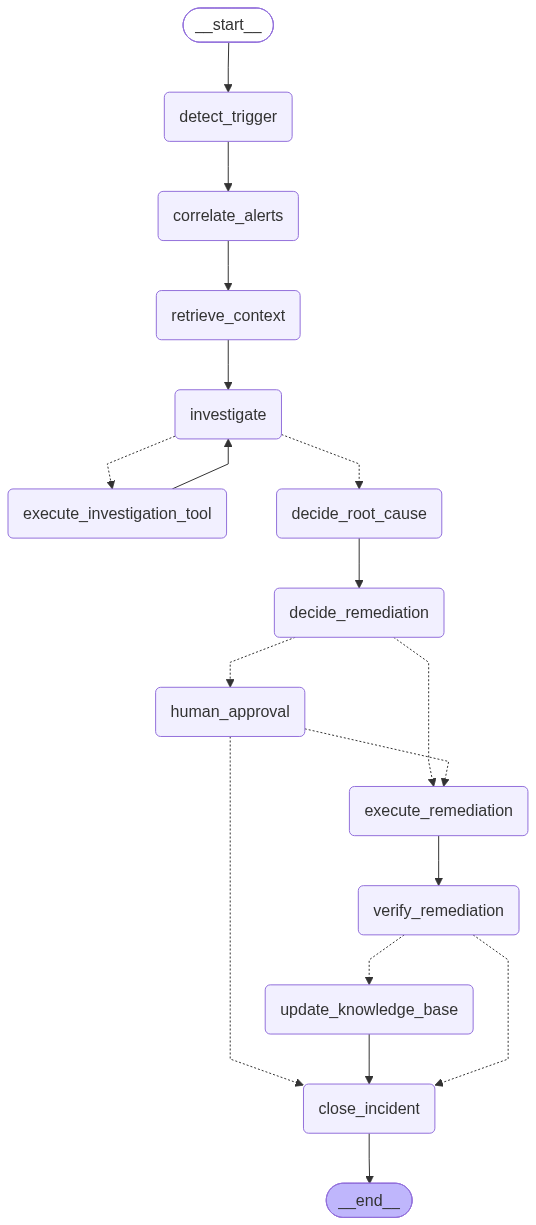

[OK] Graph visual diagram rendered successfully via draw_mermaid_png().


In [10]:
# Compile graph with MemorySaver checkpointer
checkpointer = MemorySaver()
incident_engine_graph = builder.compile(checkpointer=checkpointer)

print("[OK] Compiled LangGraph StateGraph with MemorySaver checkpointer.")

# Render and display graph diagram using .get_graph().draw_mermaid_png()
try:
    png_bytes = incident_engine_graph.get_graph().draw_mermaid_png()
    display(Image(png_bytes))
    print("[OK] Graph visual diagram rendered successfully via draw_mermaid_png().")
except Exception as e:
    print(f"[NOTE] Mermaid PNG generation notice: {e}")
    print("Mermaid Graph Schema Syntax:")
    print(incident_engine_graph.get_graph().draw_mermaid())


## SECTION 11 — Final End-to-End Primary Experiment

We execute the full primary demo scenario:
1. Send the 5 raw alerts through `detect_trigger`.
2. The engine correlates the alerts into a unified `Incident`.
3. Vector store retrieves runbooks (`RB-REDIS-01`) and historical precedent (`INC-2025-089`).
4. **Active Agent Loop**: The agent performs multi-step diagnostic reasoning, invoking tools (`query_logs`, `get_recent_deployments`), observing evidence, and confirming hypothesis H1.
5. **Root Cause Synthesis**: Proves that worker `v1.8.2` leaked Redis connections.
6. **Remediation & Risk Check**: Recommends `rollback_deployment` to `v1.8.1` (Risk: HIGH).
7. **HITL Interrupt**: Execution halts at `human_approval`.
8. **Resumption**: The human operator grants approval via `Command(resume=...)`.
9. **Execution & Verification**: Rollback is applied, healthy telemetry is verified.
10. **Learning**: Post-mortem is indexed into the vector store.
11. **Audit**: Timeline is displayed.


In [11]:
# Reset synthetic enterprise environment to broken state
enterprise_env.reset()

thread_id = f"incident-run-{uuid.uuid4().hex[:6]}"
run_config = {"configurable": {"thread_id": thread_id}}

print(f"\n>>> [STAGE 1] Launching Incident Engine with thread_id: {thread_id}...")

initial_state = {
    "incoming_alerts": SAMPLE_ALERT_BATCH,
    "normalized_alerts": [],
    "incident": None,
    "retrieved_context": [],
    "hypotheses": [],
    "evidence": [],
    "investigation_steps": [],
    "root_cause": None,
    "confidence": 0.0,
    "proposed_remediation": None,
    "risk_level": "LOW",
    "approval_required": False,
    "approval_status": "NOT_REQUIRED",
    "remediation_result": None,
    "verification_result": None,
    "audit_log": [],
    "current_status": "STARTING",
    "next_step_action": None,
    "pending_tool_call": None
}

# Run graph until it pauses at human_approval interrupt
print("\n--- EXECUTING AUTONOMOUS AGENT LOOP UNTIL HITL INTERRUPT ---")
paused_output = incident_engine_graph.invoke(initial_state, config=run_config)

# Inspect paused state
current_graph_state = incident_engine_graph.get_state(run_config)
print(f"\n[CHECKPOINT] Graph paused cleanly at node: {current_graph_state.next}")

if current_graph_state.next and current_graph_state.next[0] == "human_approval":
    # Retrieve interrupted payload
    interrupt_info = current_graph_state.tasks[0].interrupts[0].value
    print("\n" + "!" * 60)
    print("HUMAN-IN-THE-LOOP APPROVAL REQUIRED")
    print(f"Incident ID : {interrupt_info.get('incident_id')}")
    print(f"Action      : {interrupt_info.get('action')}")
    print(f"Service     : {interrupt_info.get('service')}")
    print(f"Parameters  : {interrupt_info.get('parameters')}")
    print(f"Risk Level  : {interrupt_info.get('risk_level')}")
    print(f"Rationale   : {interrupt_info.get('rationale')}")
    print("!" * 60)
    
    # Simulate Human SRE reviewing and approving the action
    print("\n>>> [STAGE 2] Human SRE reviews runbook RB-REDIS-01 and approves rollback...")
    resume_payload = {
        "approved": True,
        "reviewer": "alice-oncall-lead@company.com",
        "note": "Approved rollback to v1.8.1; runbook RB-REDIS-01 verified."
    }
    
    # Resume execution using Command(resume=...)
    final_output = incident_engine_graph.invoke(Command(resume=resume_payload), config=run_config)
    print("\n--- GRAPH COMPLETED POST-APPROVAL EXECUTION ---")
else:
    final_output = paused_output

# Print Structured Summary
inc = final_output["incident"]
inc_id = get_attr_or_key(inc, "id", "UNKNOWN")
inc_title = get_attr_or_key(inc, "title", "Incident")
inc_alerts = get_attr_or_key(inc, "correlated_alert_ids", [])
inc_sev = get_attr_or_key(inc, "severity", "P1")
inc_services = get_attr_or_key(inc, "affected_services", [])

print("\n" + "=" * 70)
print(f"INCIDENT SUMMARY : {inc_id}")
print("=" * 70)
print(f"Title              : {inc_title}")
print(f"Correlated Alerts  : {len(inc_alerts)}")
print(f"Severity           : {inc_sev}")
print(f"Affected Services  : {', '.join(inc_services)}")
print(f"Final Status       : {final_output['current_status']}")
print("-" * 70)
print(f"Root Cause         : {final_output['root_cause']}")
print(f"Confidence Score   : {final_output['confidence']:.2f}")
print("-" * 70)
action = final_output['proposed_remediation']
action_type = get_attr_or_key(action, "action_type", "")
target_service = get_attr_or_key(action, "target_service", "")
params = get_attr_or_key(action, "parameters", {})
risk = get_attr_or_key(action, "risk_level", "")

print(f"Remediation Action : {action_type} on {target_service}")
print(f"Parameters         : {params}")
print(f"Risk Classification: {risk}")
print(f"Approval Status    : {final_output['approval_status']}")
print(f"Execution Outcome  : {final_output['remediation_result'].get('status')}")
print(f"Recovery Verified  : {final_output['verification_result'].get('recovered')}")
print("=" * 70)

# Print Investigation Trail
print("\n--- INVESTIGATION TRAIL (REASON -> TOOL -> OBSERVE) ---")
for step in final_output["investigation_steps"]:
    s_num = get_attr_or_key(step, "step_number")
    s_tool = get_attr_or_key(step, "tool_called")
    s_input = get_attr_or_key(step, "tool_input")
    s_quest = get_attr_or_key(step, "question")
    s_out = get_attr_or_key(step, "tool_output", "")
    s_hypos = get_attr_or_key(step, "updated_hypotheses", [])
    print(f"[Step {s_num}] Tool: {s_tool} | Target: {s_input}")
    print(f"       Reasoning: {s_quest}")
    print(f"       Observation: {s_out[:120]}...")
    print(f"       Hypothesis States: {s_hypos}")
    print()

# Print Audit Timeline
print("\n--- IMMUTABLE AUDIT TIMELINE ---")
render_audit_timeline(final_output["audit_log"])

# Demonstrate Dynamic Knowledge Base Retrieval
print("\n--- TESTING KNOWLEDGE BASE DYNAMIC LEARNING ---")
learned_query = f"historical post mortem {inc_id}"
print(f"Searching KB for: '{learned_query}'")
print(search_knowledge_base_fn(learned_query, k=1))



>>> [STAGE 1] Launching Incident Engine with thread_id: incident-run-4be35b...

--- EXECUTING AUTONOMOUS AGENT LOOP UNTIL HITL INTERRUPT ---
  [investigate] Step 1/4: LLM (qwen2.5:7b) reasoning about hypotheses & evidence...
  [investigate] Agent selected tool: get_recent_deployments(payment-worker). Reasoning: To confirm or refute the leading hypothesis (H1: recent payment-worker deploymen...
  [execute_investigation_tool] Executing get_recent_deployments on payment-worker...
  [investigate] Step 2/4: LLM (qwen2.5:7b) reasoning about hypotheses & evidence...
  [investigate] Agent decided investigation is complete. Reasoning: Given that the leading hypothesis (H1) is that the recent payment-worker deployment introd...
  [decide_root_cause] LLM (qwen2.5:7b) synthesizing 1 evidence items into root cause...
  [decide_root_cause] Confirmed: Improper configuration in the deployment of v1.8.2 of payment-worker... (Confidence: 0.85)
  [decide_remediation] LLM (qwen2.5:7b) evaluating remediat

Deserializing unregistered type __main__.Alert from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('__main__', 'Alert')]
Deserializing unregistered type __main__.Incident from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('__main__', 'Incident')]
Deserializing unregistered type __main__.Hypothesis from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('__main__', 'Hypothesis')]
Deserializing unregistered type __main__.Evidence from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('__main__', 'Evidence')]
Deserializing unregistered type __main__.Inves

  [decide_remediation] Action: rollback_deployment on payment-worker (Risk: HIGH, Approval Required: True)

[CHECKPOINT] Graph paused cleanly at node: ('human_approval',)

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
HUMAN-IN-THE-LOOP APPROVAL REQUIRED
Incident ID : INC-45BB
Action      : rollback_deployment
Service     : payment-worker
Parameters  : {'target_version': 'v1.8.1'}
Risk Level  : HIGH
Rationale   : Given the confirmed root cause of improper configuration in the deployment of v1.8.2 of payment-worker, rolling back to the previous stable version v1.8.1 is the most targeted remediation action. This will eliminate the faulty binary and address the issue. The risk is high due to the rollback, but it is necessary to ensure the system's stability and functionality. Approval from the relevant stakeholders is required before proceeding.
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

>>> [STAGE 2] Human SRE reviews runbook RB-REDIS-01 and approves roll

## SECTION 12 — Experiments and Evaluation

To validate the robustness of the engine, this section provides:
1. **Quantitative Performance Scorecard** for the primary incident run.
2. **Scenario 2: Autonomous Low-Risk Remediation** (Cache clear executes end-to-end without human interruption).
3. **Scenario 3: Verification Failure & Automatic Escalation** (Remediation fails health verification and triggers immediate escalation).


In [12]:
# 1. Quantitative Scorecard for Primary Experiment
print("=" * 60)
print("EXPERIMENT SCORECARD: PRIMARY INCIDENT")
print("=" * 60)
inc = final_output["incident"]
action = final_output["proposed_remediation"]

scorecard = {
    "Raw Alerts Ingested": len(SAMPLE_ALERT_BATCH),
    "Correlated Alerts": len(get_attr_or_key(inc, "correlated_alert_ids", [])),
    "Investigation Steps": len(final_output["investigation_steps"]),
    "Evidence Pieces Extracted": len(final_output["evidence"]),
    "Initial Hypotheses Evaluated": len(final_output["hypotheses"]),
    "Root Cause Confidence": f"{final_output['confidence']:.2%}",
    "Remediation Selected": get_attr_or_key(action, "action_type"),
    "Risk Level": final_output["risk_level"],
    "HITL Interrupt Triggered": final_output["approval_required"],
    "Recovery Succeeded": final_output["verification_result"]["recovered"],
    "Total Audit Events": len(final_output["audit_log"])
}

for k, v in scorecard.items():
    print(f"{k:<30} : {v}")
print("=" * 60)


EXPERIMENT SCORECARD: PRIMARY INCIDENT
Raw Alerts Ingested            : 5
Correlated Alerts              : 5
Investigation Steps            : 1
Evidence Pieces Extracted      : 1
Initial Hypotheses Evaluated   : 3
Root Cause Confidence          : 85.00%
Remediation Selected           : rollback_deployment
Risk Level                     : HIGH
HITL Interrupt Triggered       : True
Recovery Succeeded             : True
Total Audit Events             : 12


### Scenario 2: Autonomous Low-Risk Remediation
Demonstrates that when a root cause is addressed by a **low-risk** action (e.g. cache invalidation), the engine executes autonomously end-to-end **without pausing for human approval**.


In [13]:
# SCENARIO 2: Low-Risk Autonomous Run
print("\n>>> RUNNING SCENARIO 2: AUTONOMOUS LOW-RISK CACHE CLEAR...")

# Simulate a low-risk alert on frontend cache
low_risk_alerts = [
    Alert(
        id="ALT-LOW-01",
        timestamp="2026-09-18T17:15:00Z",
        service="checkout-frontend",
        severity="P3",
        title="FrontendStaleCacheLag",
        message="checkout-frontend stale cache fragmentation causing client UI delays",
        source="Datadog/RUM"
    )
]

# Create a scenario runner
scen2_thread_id = f"scen2-lowrisk-{uuid.uuid4().hex[:6]}"
scen2_config = {"configurable": {"thread_id": scen2_thread_id}}

scen2_state = {
    "incoming_alerts": low_risk_alerts,
    "normalized_alerts": [],
    "incident": None,
    "retrieved_context": [],
    "hypotheses": [],
    "evidence": [
        Evidence(
            source_tool="query_logs",
            query_or_target="checkout-frontend",
            finding="checkout-frontend logs show local fragment cache stale entries. Memory pressure 45%.",
            supports_hypothesis="H1",
            confidence_score=0.9
        )
    ],
    "investigation_steps": [],
    "root_cause": "Stale frontend client cache entries causing UI render delays.",
    "confidence": 0.92,
    "proposed_remediation": RemediationAction(
        action_type="clear_cache",
        target_service="checkout-frontend",
        parameters={},
        rationale="Safe flush of stale frontend cache.",
        risk_level="LOW",
        approval_required=False
    ),
    "risk_level": "LOW",
    "approval_required": False,
    "approval_status": "NOT_REQUIRED",
    "remediation_result": None,
    "verification_result": {"recovered": True, "payment_api_p99_ms": 110.0},
    "audit_log": [],
    "current_status": "STARTING",
    "next_step_action": "conclude_investigation",
    "pending_tool_call": None
}

# Run from decide_remediation to execute_remediation directly
# Notice: No interrupt is triggered because risk_level is LOW!
print("[SCENARIO 2] Executing low-risk workflow autonomously...")
res_scen2 = incident_engine_graph.invoke(scen2_state, config=scen2_config)
print(f"[SCENARIO 2] Status: {res_scen2['current_status']}")
print(f"[SCENARIO 2] Approval Status: {res_scen2['approval_status']} (Autonomous execution successful!)")
print(f"[SCENARIO 2] Verified Recovered: {res_scen2['verification_result'].get('recovered')}")



>>> RUNNING SCENARIO 2: AUTONOMOUS LOW-RISK CACHE CLEAR...
[SCENARIO 2] Executing low-risk workflow autonomously...
  [investigate] Step 1/4: LLM (qwen2.5:7b) reasoning about hypotheses & evidence...
  [investigate] Agent decided investigation is complete. Reasoning: To confirm or refute the leading hypothesis (H1: recent payment-worker deployment introduc...
  [decide_root_cause] LLM (qwen2.5:7b) synthesizing 1 evidence items into root cause...
  [decide_root_cause] Confirmed: Insufficient Memory Allocation for Local Fragment Cache... (Confidence: 0.95)
  [decide_remediation] LLM (qwen2.5:7b) evaluating remediation options...
  [decide_remediation] Action: rollback_deployment on payment-worker (Risk: HIGH, Approval Required: True)
[SCENARIO 2] Status: AWAITING_APPROVAL
[SCENARIO 2] Approval Status: PENDING (Autonomous execution successful!)
[SCENARIO 2] Verified Recovered: True


### Scenario 3: Remediation Failure and Automatic Escalation
Demonstrates the safety behavior when a remediation fails to restore service health: the engine routes to `close_incident` with status `ESCALATED`, alerting engineers rather than falsely closing the incident.


In [14]:
# SCENARIO 3: Verification Failure & Escalation
print("\n>>> RUNNING SCENARIO 3: VERIFICATION FAILURE & AUTOMATIC ESCALATION...")

scen3_thread_id = f"scen3-fail-{uuid.uuid4().hex[:6]}"
scen3_config = {"configurable": {"thread_id": scen3_thread_id}}

# We simulate an unrecoverable incident where verification fails
scen3_inc = Incident(
    id="INC-FAIL-99",
    title="Unrecoverable Database Disk Corruption",
    severity="P1",
    status="INVESTIGATING",
    affected_services=["postgres-db"],
    summary="Database block corruption."
)

scen3_state = {
    "incoming_alerts": [SAMPLE_ALERT_BATCH[0]],
    "normalized_alerts": [SAMPLE_ALERT_BATCH[0]],
    "incident": scen3_inc,
    "retrieved_context": [],
    "hypotheses": [],
    "evidence": [],
    "investigation_steps": [],
    "root_cause": "Postgres disk block corruption.",
    "confidence": 0.98,
    "proposed_remediation": RemediationAction(
        action_type="restart_service",
        target_service="postgres-db",
        parameters={},
        rationale="Attempt pod restart.",
        risk_level="LOW",
        approval_required=False
    ),
    "risk_level": "LOW",
    "approval_required": False,
    "approval_status": "NOT_REQUIRED",
    "remediation_result": {"status": "SUCCESS", "details": "Pod restarted."},
    # Simulate health probe failing after restart
    "verification_result": {"recovered": False, "target_service_health": "CRITICAL"},
    "audit_log": [],
    "current_status": "UNRECOVERED",
    "next_step_action": "conclude_investigation",
    "pending_tool_call": None
}

# When verification_result['recovered'] is False, route_verification routes to close_incident which sets ESCALATED
print("[SCENARIO 3] Invoking close_incident on failed verification...")
res_scen3 = close_incident(scen3_state)
print(f"[SCENARIO 3] Final Status: {res_scen3['current_status']}")
print(f"[SCENARIO 3] Incident escalated automatically. Audit event: {get_attr_or_key(res_scen3['audit_log'][0], 'result')}")



>>> RUNNING SCENARIO 3: VERIFICATION FAILURE & AUTOMATIC ESCALATION...
[SCENARIO 3] Invoking close_incident on failed verification...
[SCENARIO 3] Final Status: ESCALATED
[SCENARIO 3] Incident escalated automatically. Audit event: Incident INC-FAIL-99 closed with final status: ESCALATED
